<a href="https://colab.research.google.com/github/kanchan874/Machine_vision/blob/main/MV_PR5_CM23004.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import cv2
import os
import zipfile
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

In [2]:
uploaded = files.upload()

Saving archive (4).zip to archive (4).zip


In [3]:
zip_name = list(uploaded.keys())[0]

with zipfile.ZipFile(zip_name, 'r') as zip_ref:
    zip_ref.extractall()

print("Dataset Extracted Successfully!")

Dataset Extracted Successfully!


In [4]:
face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
)

eye_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_eye.xml"
)

In [5]:
dataset_path = "test"

image_paths = []

for root, dirs, files in os.walk(dataset_path):
    for file in files:
        if file.lower().endswith((".jpg", ".jpeg", ".png")):
            image_paths.append(os.path.join(root, file))

print("Total Images:", len(image_paths))

Total Images: 164


In [6]:
total_images = 0
face_detected = 0

results = []

for path in image_paths:

    image = cv2.imread(path)

    if image is None:
        continue

    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    faces = face_cascade.detectMultiScale(
        gray,
        scaleFactor=1.1,
        minNeighbors=5,
        minSize=(30,30)
    )

    total_images += 1

    if len(faces) > 0:
        face_detected += 1

    for (x,y,w,h) in faces:

        cv2.rectangle(image,(x,y),(x+w,y+h),(255,0,0),2)

        roi_gray = gray[y:y+h,x:x+w]
        roi_color = image[y:y+h,x:x+w]

        eyes = eye_cascade.detectMultiScale(roi_gray)

        for (ex,ey,ew,eh) in eyes:

            cv2.rectangle(
                roi_color,
                (ex,ey),
                (ex+ew,ey+eh),
                (0,255,0),
                2
            )

    results.append(image)

In [7]:
accuracy = (face_detected / total_images) * 100

print("Total Images :", total_images)
print("Faces Detected :", face_detected)
print("Detection Accuracy : {:.2f}%".format(accuracy))

Total Images : 164
Faces Detected : 98
Detection Accuracy : 59.76%


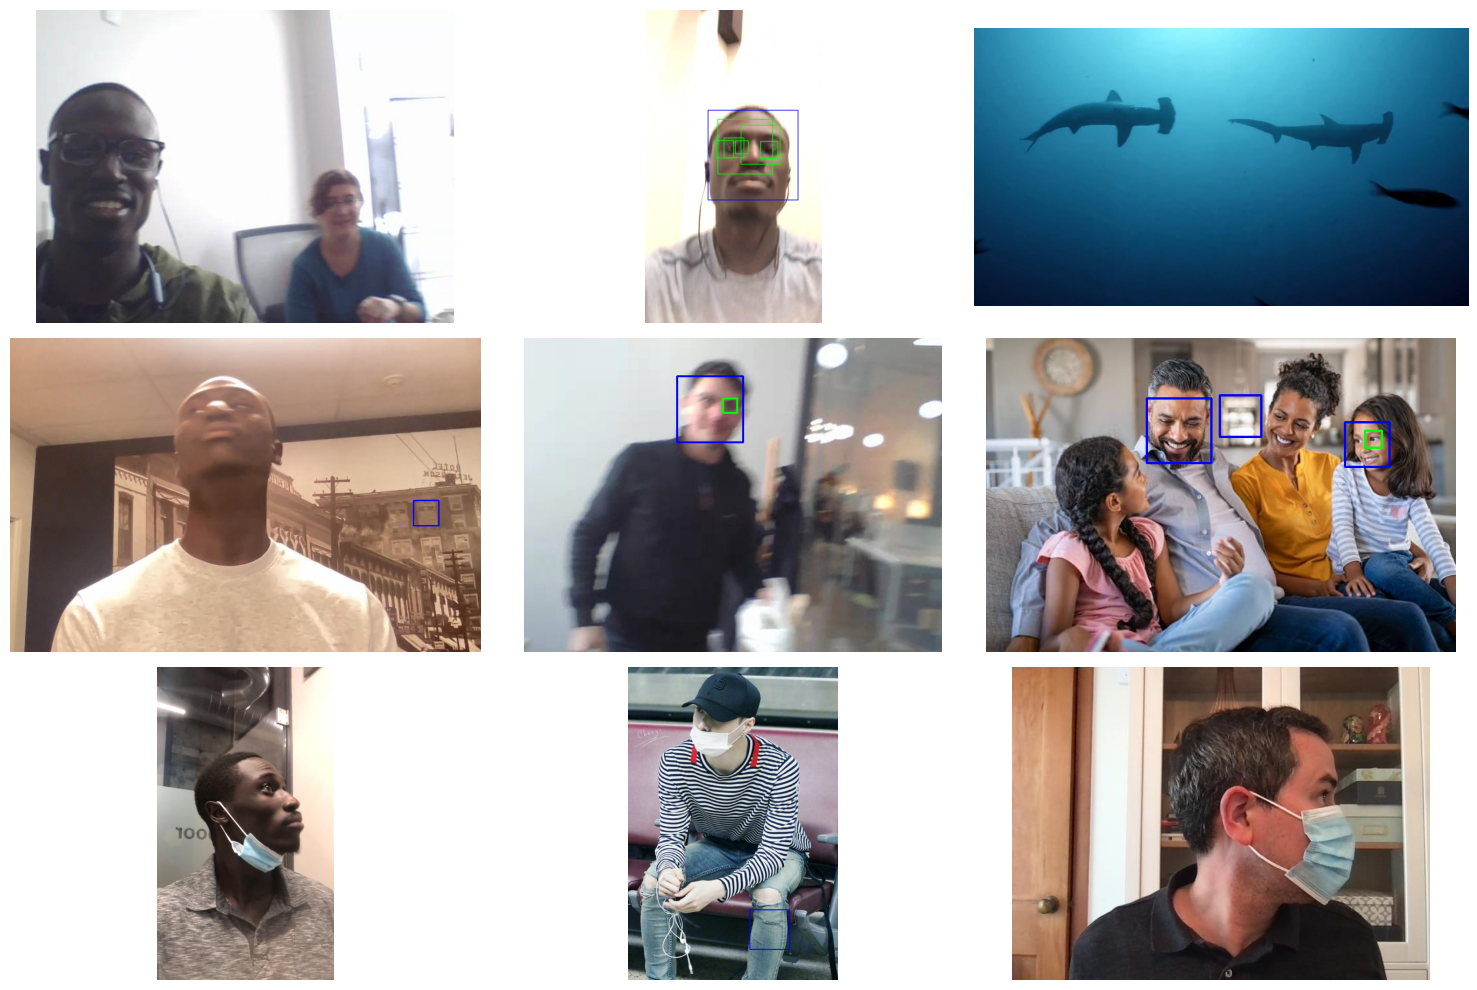

In [8]:
plt.figure(figsize=(15,10))

samples = min(9, len(results))

for i in range(samples):

    plt.subplot(3,3,i+1)

    rgb = cv2.cvtColor(results[i], cv2.COLOR_BGR2RGB)

    plt.imshow(rgb)

    plt.axis("off")

plt.tight_layout()
plt.show()

In [9]:
bright = 0
normal = 0
dark = 0

bright_detect = 0
normal_detect = 0
dark_detect = 0

for path in image_paths:

    image = cv2.imread(path)

    if image is None:
        continue

    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    brightness = np.mean(gray)

    if brightness > 170:
        bright += 1
        category = "bright"

    elif brightness < 80:
        dark += 1
        category = "dark"

    else:
        normal += 1
        category = "normal"

    faces = face_cascade.detectMultiScale(gray,1.1,5)

    if len(faces)>0:

        if category=="bright":
            bright_detect += 1

        elif category=="dark":
            dark_detect += 1

        else:
            normal_detect += 1

In [10]:
print("Lighting Condition Evaluation\n")

if bright != 0:
    print("Bright Accuracy : {:.2f}%".format((bright_detect/bright)*100))

if normal != 0:
    print("Normal Accuracy : {:.2f}%".format((normal_detect/normal)*100))

if dark != 0:
    print("Dark Accuracy : {:.2f}%".format((dark_detect/dark)*100))

Lighting Condition Evaluation

Bright Accuracy : 64.71%
Normal Accuracy : 59.26%
Dark Accuracy : 66.67%


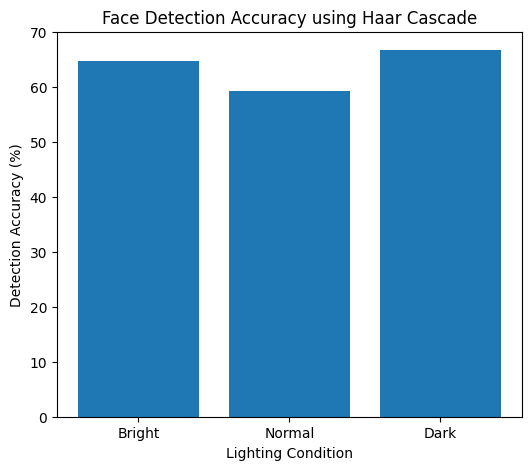

In [11]:
labels = []
values = []

if bright != 0:
    labels.append("Bright")
    values.append((bright_detect/bright)*100)

if normal != 0:
    labels.append("Normal")
    values.append((normal_detect/normal)*100)

if dark != 0:
    labels.append("Dark")
    values.append((dark_detect/dark)*100)

plt.figure(figsize=(6,5))

plt.bar(labels, values)

plt.xlabel("Lighting Condition")
plt.ylabel("Detection Accuracy (%)")
plt.title("Face Detection Accuracy using Haar Cascade")

plt.show()